In [1]:
from pathlib import Path
from test_vectorized import read_audio_chunk, compute_template_dtw_costs, load_threshold, load_template_segment, batch_stft_windows, dtw_costs_vectorized
from stft import plot_spectrogram
import json
import numpy as np

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

In [2]:
st_temps = RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json"
mt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json"
bt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json"

#load template data from .json file
with open(st_temps) as f:
    st_templates = json.load(f)

with open(mt_temps) as f:
    mt_templates = json.load(f)

with open(bt_temps) as f:
    bt_templates = json.load(f)

st_templates = st_templates[:5]
mt_templates = mt_templates[:5]
bt_templates = bt_templates[:5]

st_stfts = [load_template_segment(t, 1000) for t in st_templates]
mt_stfts = [load_template_segment(t, 1000) for t in mt_templates]
bt_stfts = [load_template_segment(t, 1000) for t in bt_templates]

Load thresholds

In [3]:
st = load_threshold(file_label = "20230429_Templates", 
               call_type = "single_tone", 
               results_dir = RESULTS_29)

st_threshold = st["threshold"]

mt = load_threshold(file_label = "20230429_Templates", 
               call_type = "multi_tone", 
               results_dir = RESULTS_29)

mt_threshold = mt["threshold"]

bt = load_threshold(file_label = "20230429_Templates", 
               call_type = "burst_tonal", 
               results_dir = RESULTS_29)

bt_threshold = bt["threshold"]

print(f"Single Tone Threshold: {st_threshold}")
print(f"Multi Tone Threshold: {mt_threshold}")
print(f"Burst Tonal Threshold: {bt_threshold}")

Single Tone Threshold: 0.16292170638658898
Multi Tone Threshold: 0.17513743191345682
Burst Tonal Threshold: 0.15166169445617353


Load 72 hour audio in 1 hour segments

In [33]:
all_detected_t = []       # global list, accumulates across all hours
all_detected_labels = []  # optional: keep track of call type too

for i in range(2):
    #print(f"Processing hour {i+1} of 72")
    #load 1 hour of audio and resample to fs = 1000Hz
    f_s, audio_array = read_audio_chunk(DATA_22 / "20230422_171301.wav", i, duration_hour=1.0, fs_new=1000)

    #split audio into windows and store in a vector and calculate STFT for each window
    f_win, t_win,Zxx_window = batch_stft_windows(audio_array, 
                                                window_len = int(0.15*1000), 
                                                step_len = int(0.15*1000/2), 
                                                fs_new = f_s, 
                                                framelength = int(f_s * 0.128), 
                                                noverlap = int(int(f_s * 0.128) * 0.75))

    costs_st, costs_mt, costs_bt = dtw_costs_vectorized(st_stfts, 
                                                    mt_stfts, 
                                                    bt_stfts, 
                                                    n_templates = 5, 
                                                    audio_segment = Zxx_window)  

    '''n_windows = Zxx_window.shape[0]
    call_detected = np.zeros(n_windows, dtype=bool)
    call_labels = np.full(n_windows, "", dtype=object)

    for costs_list, threshold, label in [(costs_st, st_threshold, "st"),
                                        (costs_mt, mt_threshold, "mt"),
                                        (costs_bt, bt_threshold, "bt")]:
        costs_arr = np.vstack(costs_list)        # shape: (n_templates, n_windows)
        below_thresh = costs_arr < threshold     # shape: (n_templates, n_windows)
        triggered = below_thresh.any(axis=0)     # shape: (n_windows,) -- True if ANY template hit

        # only tag windows that haven't already been tagged by an earlier call type
        newly_triggered = triggered & ~call_detected
        call_labels[newly_triggered] = label
        call_detected |= triggered'''
    # compute votes/mean_cost for all three call types first, then decide winner per window
    results = {}
    for costs_list, threshold, label in [(costs_st, st_threshold, "st"),
                                        (costs_mt, mt_threshold, "mt"),
                                        (costs_bt, bt_threshold, "bt")]:
        costs_arr = np.vstack(costs_list)
        n_templates = costs_arr.shape[0]
        votes = (costs_arr < threshold).sum(axis=0)
        mean_cost = costs_arr.mean(axis=0)
        triggered = votes >= np.ceil(0.6 * n_templates)
        results[label] = (triggered, mean_cost)

    n_windows = Zxx_window.shape[0]
    call_detected = np.zeros(n_windows, dtype=bool)
    call_labels = np.full(n_windows, "", dtype=object)
    best_cost = np.full(n_windows, np.inf)

    for label, (triggered, mean_cost) in results.items():
        better = triggered & (mean_cost < best_cost)
        call_labels[better] = label
        best_cost[better] = mean_cost[better]
        call_detected |= triggered
    print(f"Processing hour {i+1} of 72: {call_detected.sum()} / {n_windows} windows flagged as calls")

    detected = np.where(call_detected)[0]
    detected_t = detected*75/1000
    detected_t_global = detected_t + i*3600

    # accumulate
    all_detected_t.extend(detected_t_global.tolist())
    all_detected_labels.extend(call_labels[detected].tolist())

    #for d in detected_t:
    #   print(f"Call detected at {d:.3f} seconds array index {int(d*1000/75)}")
# after the loop, convert to arrays for downstream use
all_detected_t = np.array(all_detected_t)
all_detected_labels = np.array(all_detected_labels, dtype=object)

print(f"\nTotal detections across all 72 hours: {len(all_detected_t)}")

Processing hour 1 of 72: 58 / 47999 windows flagged as calls
Processing hour 2 of 72: 19 / 47999 windows flagged as calls

Total detections across all 72 hours: 77


In [34]:
step = 0.075       # step_len in seconds (150ms window, 50% overlap -> 75ms step)
window_len = 0.15  # window length in seconds
tol = 1e-6         # floating point tolerance

combined_calls = []  # list of (start_time, end_time, label)

if len(all_detected_t) > 0:
    run_start = all_detected_t[0]
    run_end   = all_detected_t[0]
    run_label = all_detected_labels[0]

    for t, label in zip(all_detected_t[1:], all_detected_labels[1:]):
        gap = t - run_end
        is_consecutive = np.isclose(gap, step, atol=tol)

        if is_consecutive and label == run_label:
            # extend the current run
            run_end = t
        else:
            # close out the current run, start a new one
            combined_calls.append((run_start, run_end + window_len, run_label))
            run_start = t
            run_end = t
            run_label = label

    # don't forget to flush the last run after the loop ends
    combined_calls.append((run_start, run_end + window_len, run_label))

print(f"Merged {len(all_detected_t)} raw window detections into {len(combined_calls)} calls")

Merged 77 raw window detections into 46 calls


In [35]:
print(combined_calls[4])

(np.float64(993.675), np.float64(993.9), 'mt')


1 hour seg code

In [19]:
#load 1 hour of audio and resample to fs = 1000Hz
f_s, audio_array = read_audio_chunk(DATA_22 / "20230422_171301.wav", 0.0, duration_hour=1.0, fs_new=1000)

Split Audio into windows

In [20]:
#split audio into windows and store in a vector and calculate STFT for each window
f_win, t_win,Zxx_window = batch_stft_windows(audio_array, 
                                             window_len = int(0.15*1000), 
                                             step_len = int(0.15*1000/2), 
                                             fs_new = f_s, 
                                             framelength = int(f_s * 0.128), 
                                             noverlap = int(int(f_s * 0.128) * 0.75))

Calculate Costs

In [21]:
costs_st, costs_mt, costs_bt = dtw_costs_vectorized(st_stfts, 
                                                    mt_stfts, 
                                                    bt_stfts, 
                                                    n_templates = 5, 
                                                    audio_segment = Zxx_window)

In [22]:
n_windows = Zxx_window.shape[0]
call_detected = np.zeros(n_windows, dtype=bool)
call_labels = np.full(n_windows, "", dtype=object)

for costs_list, threshold, label in [(costs_st, st_threshold, "st"),
                                      (costs_mt, mt_threshold, "mt"),
                                      (costs_bt, bt_threshold, "bt")]:
    costs_arr = np.vstack(costs_list)        # shape: (n_templates, n_windows)
    below_thresh = costs_arr < threshold     # shape: (n_templates, n_windows)
    triggered = below_thresh.any(axis=0)     # shape: (n_windows,) -- True if ANY template hit

    # only tag windows that haven't already been tagged by an earlier call type
    newly_triggered = triggered & ~call_detected
    call_labels[newly_triggered] = label
    call_detected |= triggered

print(f"\n{call_detected.sum()} / {n_windows} windows flagged as calls")


165 / 47999 windows flagged as calls


In [ ]:
detected = np.where(call_detected)[0]
detected_t = detected*75/1000
for d in detected_t:
    print(f"Call detected at {d:.3f} seconds array index {int(d*1000/75)}")

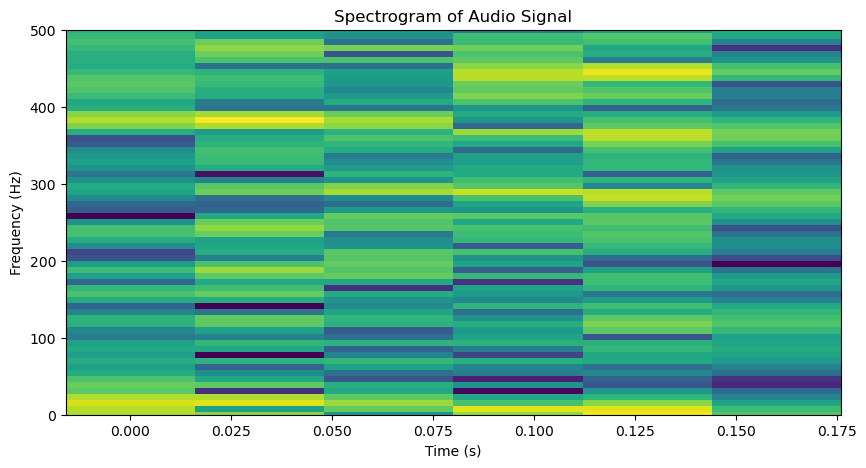

In [36]:
plot_spectrogram(f_win, t_win, Zxx_window[13249], 1000)